In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (LabelEncoder,OneHotEncoder,FunctionTransformer,StandardScaler)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score,ConfusionMatrixDisplay)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


#Affichage complet des colonnes et des lignes (pas de retour a la ligne)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)

#Import du fichier csv customer
url = "./../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url,sep=",",skipinitialspace=True)



# Affichage des dimension du jeu de données
print(f"Le jeu de données a {df.shape[0]} lignes et {df.shape[1]} colonnes")

# Affichez les 5 premières lignes
print(df.head())
display(df.info())


Le jeu de données a 7043 lignes et 21 colonnes
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85         29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.50    No
2  3668-QPYBK    Male              0      No         No       2          Yes 

None

Séparation des datas

In [177]:

# je vais spliter le data set en 3 parties:df_val 10% et sur le reste df_train 80% et df_test 20%
# utilisation de train_test_split pour garder une bonne repartition de churn
 

 
 
# 1. Mise de côté de 10% pour la validation finale
 
 
df_without_val, df_val = train_test_split(
    df,
    test_size=0.10,
    random_state=42,
    stratify=df["Churn"]
)

# 2. Split des 90% restants en train/test 80/20
df_train, df_test = train_test_split(
    df_without_val,
    test_size=0.20,
    random_state=42,
    stratify=df_without_val["Churn"]
)
print(f"Le jeu de validation a {df_val.shape[0]} lignes et {df_val.shape[1]} colonnes")
print(f"Le jeu de d'entrainement a {df_train.shape[0]} lignes et {df_train.shape[1]} colonnes")
print(f"Le jeu de test a {df_test.shape[0]} lignes et {df_test.shape[1]} colonnes")
 

Le jeu de validation a 705 lignes et 21 colonnes
Le jeu de d'entrainement a 5070 lignes et 21 colonnes
Le jeu de test a 1268 lignes et 21 colonnes


In [ ]:



# Initialisation de l'encodeur
le = LabelEncoder()



features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "PaymentMethod",
    "OnlineSecurity",
    "InternetService",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaperlessBilling",
    "Dependents",
    "Partner",
    "SeniorCitizen"
]


X_train = df_train[features].copy()
X_test = df_test[features].copy()

X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()

y_train = le.fit_transform(df_train["Churn"].values)
y_test = le.transform(df_test["Churn"].values)


Creation du pipeline

In [179]:

num_cols = ["tenure", "MonthlyCharges","SeniorCitizen","TotalCharges"]

cat_cols = ["InternetService", "PaymentMethod", "Contract", "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","PaperlessBilling","Dependents","Partner"]



def fill_total_charge(X):
    """
    Remplace les valeurs manquantes de la colonne TotalCharges.

    Les valeurs manquantes sont estimées à partir de la formule :
    TotalCharges = tenure * MonthlyCharges.

    Parameters
    ----------
    X : pandas.DataFrame
        DataFrame contenant au minimum les colonnes `TotalCharges`,
        `tenure` et `MonthlyCharges`.

    Returns
    -------
    pandas.DataFrame
        Copie du DataFrame d'entrée avec les valeurs manquantes de
        `TotalCharges` complétées.
    """
    
    X = X.copy()
    m = X["TotalCharges"].isna()
    X.loc[m, "TotalCharges"] = X.loc[m, "tenure"] * X.loc[m, "MonthlyCharges"]
    return X

num_pipe = make_pipeline(
    FunctionTransformer(fill_total_charge, validate=False, feature_names_out="one-to-one"),
    StandardScaler()
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Creation des models

In [180]:
models = {
    
    "Dummy": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    )
}

Creation de chaque pipeline puis entrainement

In [198]:
pipelines = {
    name: make_pipeline(preprocessor, model)
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} entraîné") 
    


Dummy entraîné
Logistic Regression entraîné
Random Forest entraîné
Gradient Boosting entraîné
XGBoost entraîné
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1345, number of negative: 3725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 5070, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM entraîné


In [182]:
#un par pipeline sinon il n'affiche que je dernier
pipelines["Dummy"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('dummyclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [183]:
pipelines["Logistic Regression"]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [184]:
pipelines["Random Forest"]


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [185]:
pipelines["Gradient Boosting"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

In [186]:
pipelines["XGBoost"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [187]:
pipelines["LightGBM"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('lgbmclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [188]:
def precision_at_k_percent(y_true, y_proba, k=10):
    """
    Calcule la précision parmi les k% d'observations les plus risquées.

    Les observations sont triées par probabilité prédite de churn décroissante.
    La fonction sélectionne ensuite les k% avec les scores les plus élevés,
    puis calcule la proportion de vrais churners dans ce sous-ensemble.

    Parameters
    ----------
    y_true : array-like
        Valeurs réelles de la cible, encodées en 0/1.
        1 correspond à un client ayant churné.
    y_proba : array-like
        Probabilités prédites de churn pour chaque observation.
    k : int or float, default=10
        Pourcentage d'observations à sélectionner parmi les plus risquées.

    Returns
    -------
    float
        Précision dans le top k%, c'est-à-dire la proportion de vrais churners
        parmi les clients ayant les probabilités de churn les plus élevées.
    """
    n = int(len(y_true) * k / 100)
    
    top_idx = np.argsort(y_proba)[::-1][:n]
    
    return y_true[top_idx].mean()

# Liste qui stockera les métriques de performance de chaque modèle
results = []

# Boucle sur chaque pipeline entraîné
for name, pipe in pipelines.items():

    # Prédiction de la classe finale sur le jeu de test
    y_pred = pipe.predict(X_test)

    # Récupération de la probabilité prédite de churn
    # La classe positive correspond à Churn = Yes, donc colonne [:, 1]
    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        # Sécurité pour les modèles qui ne fourniraient pas de probabilités !!!!!!!!!!!!
        y_proba = y_pred

    # Calcul des métriques classiques
    roc_auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Calcul de la métrique métier :
    # proportion de vrais churners parmi les 10% de clients les plus risqués
    precision_top_10 = precision_at_k_percent(y_test, y_proba, k=10)

    # Sauvegarde des résultats dans une liste de dictionnaires
    results.append({
        "model": name,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "precision@10%": precision_top_10
    })

    # Affichage détaillé pour chaque modèle
    print(f"\n===== {name} =====")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report :")
    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

# Transformation des résultats en DataFrame
# Tri par precision@10%, car c'est la métrique la plus liée au ciblage marketing
results_df = pd.DataFrame(results).sort_values("precision@10%", ascending=False)

results_df


c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Dev\Projet_DataGong\.


===== Dummy =====
Matrice de confusion :
[[931   0]
 [337   0]]

Classification report :
              precision    recall  f1-score   support

          No       0.73      1.00      0.85       931
         Yes       0.00      0.00      0.00       337

    accuracy                           0.73      1268
   macro avg       0.37      0.50      0.42      1268
weighted avg       0.54      0.73      0.62      1268


===== Logistic Regression =====
Matrice de confusion :
[[666 265]
 [ 61 276]]

Classification report :
              precision    recall  f1-score   support

          No       0.92      0.72      0.80       931
         Yes       0.51      0.82      0.63       337

    accuracy                           0.74      1268
   macro avg       0.71      0.77      0.72      1268
weighted avg       0.81      0.74      0.76      1268


===== Random Forest =====
Matrice de confusion :
[[679 252]
 [ 66 271]]

Classification report :
              precision    recall  f1-score   support


,model,roc_auc,precision,recall,f1_score,precision@10%
1,Logistic Regression,0.846089,0.510166,0.818991,0.628702,0.753968
4,XGBoost,0.845897,0.674603,0.504451,0.577250,0.738095
2,Random Forest,0.848340,0.518164,0.804154,0.630233,0.730159
3,Gradient Boosting,0.850693,0.683398,0.525223,0.593960,0.714286
5,LightGBM,0.831751,0.542670,0.735905,0.624685,0.698413
0,Dummy,0.500000,0.000000,0.000000,0.000000,0.261905


### Analyse des résultats par modèle


La `Logistic Regression` obtient un très bon compromis pour l’objectif métier. Son ROC-AUC est élevé, à 0.846, et elle présente le meilleur rappel sur la classe churn, avec 81.90%. Cela signifie qu’elle détecte une grande partie des clients qui churnent réellement. Sa précision est plus faible, à 51.02%, ce qui indique qu’elle génère aussi beaucoup de faux positifs. En revanche, elle obtient la meilleure `precision@10%`, avec 75.40%. Cela signifie que parmi les 10% de clients les plus risqués selon le modèle, environ 75% sont réellement des churners.

`XGBoost` obtient un ROC-AUC très proche de la régression logistique, à 0.846. Il a une précision plus élevée, à 67.46%, ce qui signifie que ses prédictions positives sont plus fiables. En revanche, son rappel est plus faible, à 50.45%, donc il rate davantage de churners. Sa `precision@10%` est très bonne, à 73.81%, ce qui en fait un modèle intéressant pour un ciblage marketing limité.

La `Random Forest` obtient le meilleur ROC-AUC après le Gradient Boosting, avec 0.848. Son rappel est élevé, à 80.42%, proche de celui de la régression logistique. Sa précision reste modérée, à 51.82%, ce qui indique un nombre important de faux positifs. Sa `precision@10%` est de 73.02%, ce qui reste performant pour identifier les clients les plus à risque.

Le `Gradient Boosting` obtient le meilleur ROC-AUC global, à 0.851. Il présente aussi la meilleure précision classique, à 68.34%, ce qui signifie qu’il cible mieux les churners lorsqu’il prédit la classe `Yes`. En revanche, son rappel est plus faible, à 52.52%. Sa `precision@10%` est de 71.43%, correcte mais inférieure à celle de la régression logistique, de XGBoost et de la Random Forest.

`LightGBM` obtient un ROC-AUC de 0.832, inférieur aux autres modèles principaux. Son rappel reste bon, à 73.59%, et son F1-score est proche de celui de la régression logistique et de la Random Forest. En revanche, sa `precision@10%` est de 69.84%, ce qui le rend moins performant pour le ciblage prioritaire des 10% de clients les plus à risque.

Le `DummyClassifier` sert de baseline naïve. Il obtient un ROC-AUC de 0.50, ce qui correspond à une performance aléatoire. Sa précision, son rappel et son F1-score sur la classe churn sont égaux à 0, car il ne détecte aucun churner. Sa `precision@10%` est de 26.19%, proche du taux global de churn, ce qui confirme qu’il n’apporte pas de valeur pour le ciblage.


Globalement, les résultats montrent que les modèles sont performants, avec des ROC-AUC compris entre 0.832 et 0.851 pour les modèles principaux. Le `Gradient Boosting` obtient le meilleur ROC-AUC et la meilleure précision classique, mais la `Logistic Regression` obtient la meilleure `precision@10%` et le meilleur rappel. Dans le contexte métier du projet, où l’objectif est de prioriser les clients les plus à risque avec un budget marketing limité, la `Logistic Regression` apparaît donc comme le modèle le plus pertinent à ce stade.



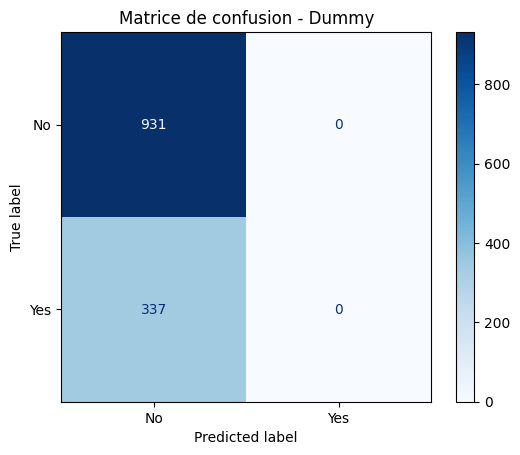

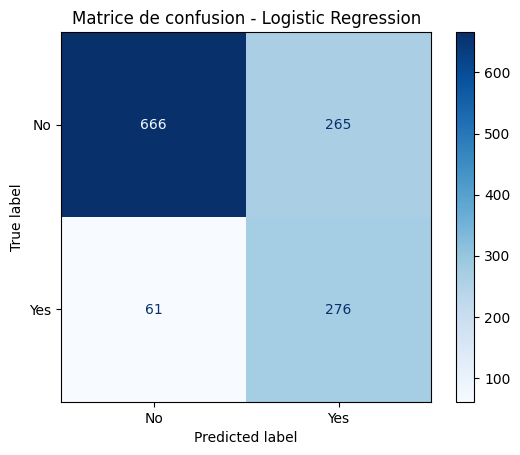

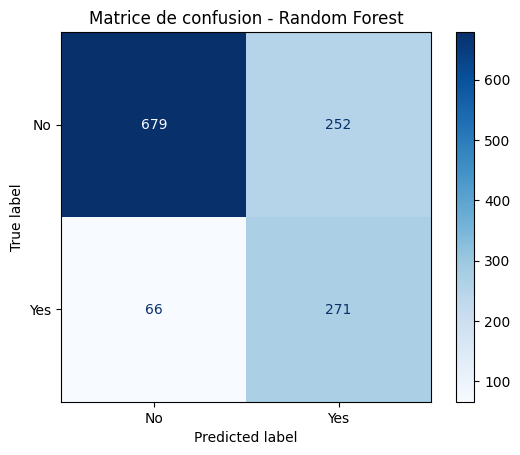

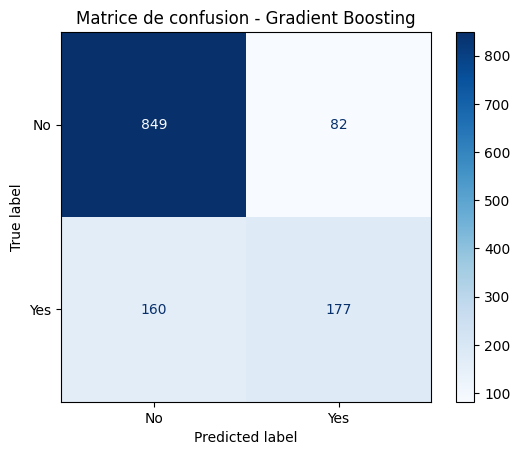

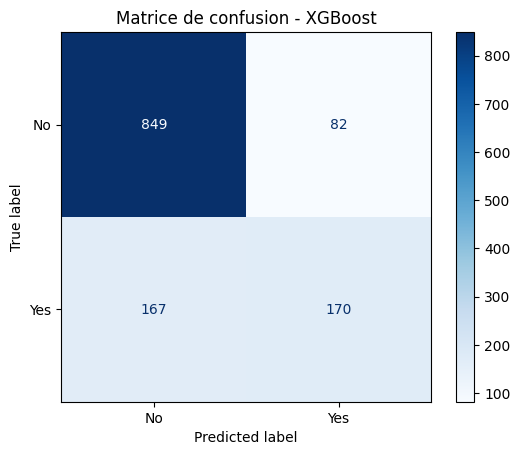

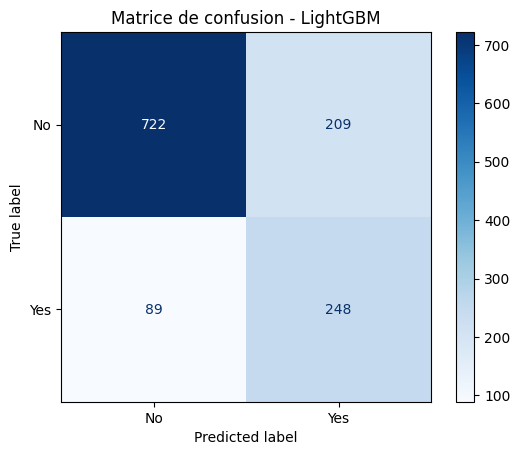

In [190]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=le.classes_,
        cmap="Blues"
    )
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

Le `DummyClassifier` prédit uniquement la classe majoritaire `No`. Il obtient donc beaucoup de vrais négatifs, mais ne détecte aucun client churner. Son rappel sur la classe `Yes` est égal à 0, ce qui confirme qu’il sert uniquement de baseline naïve.

La `Logistic Regression` détecte une grande partie des churners : elle identifie 276 churners sur 337. Son rappel sur la classe `Yes` est donc élevé. En revanche, elle génère aussi beaucoup de faux positifs avec 265 clients prédits churn alors qu’ils ne churnent pas. Ce modèle est intéressant si l’objectif est de ne pas manquer les clients à risque, mais il peut entraîner un coût marketing plus important.

La `Random Forest` a un comportement proche de la régression logistique. Elle détecte 271 churners sur 337, avec 252 faux positifs. Elle offre donc un bon rappel sur le churn, mais reste coûteuse en actions marketing inutiles.

Le `Gradient Boosting` est plus sélectif : il produit seulement 82 faux positifs, ce qui améliore la précision. En revanche, il rate davantage de churners, avec 160 faux négatifs. Ce modèle est plus adapté si le budget marketing est très limité et que l’on veut éviter de cibler trop de clients qui ne churneront pas.

`XGBoost` présente un profil similaire au Gradient Boosting. Il limite les faux positifs, mais rate 167 churners. Il est donc plus précis, mais moins sensible à la détection globale des churners.

`LightGBM` propose un compromis intéressant : il détecte 248 churners sur 337, tout en générant 209 faux positifs. Il se situe entre les modèles très sensibles comme la Logistic Regression et les modèles plus sélectifs comme Gradient Boosting ou XGBoost.

Globalement, les matrices de confusion montrent un compromis clair entre rappel et précision. La Logistic Regression et la Random Forest détectent davantage de churners, tandis que Gradient Boosting et XGBoost ciblent moins de clients à tort mais manquent plus de churners. Le choix final doit donc être confirmé avec les métriques orientées ciblage, notamment `precision@10%`.

In [191]:
import joblib
from pathlib import Path

# Création des dossiers de sortie
Path("../models").mkdir(exist_ok=True)
Path("../outputs").mkdir(exist_ok=True)

# Choix du modèle final Logistic Regression
best_model_name = "Logistic Regression"
best_pipeline = pipelines[best_model_name]

# Sauvegarde du pipeline complet : preprocessing + modèle
joblib.dump(best_pipeline, "../models/churn_model_logistic_regression.joblib")

print("Modèle sauvegardé.")

Modèle sauvegardé.


In [192]:
# Probabilité de churn sur le jeu de test
proba_churn = best_pipeline.predict_proba(X_test)[:, 1]

# Création du fichier de scoring
scoring_test = pd.DataFrame({
    "customerID": df_test["customerID"].values,
    "proba_churn": proba_churn
})

# Tri des clients du plus risqué au moins risqué
scoring_test = scoring_test.sort_values("proba_churn", ascending=False)

# Sauvegarde en CSV
scoring_test.to_csv("../outputs/scoring_test.csv", index=False)

scoring_test.head(10)

,customerID,proba_churn
67,7024-OHCCK,0.911108
721,5150-ITWWB,0.911028
238,4826-XTSOH,0.909939
76,5192-EBGOV,0.909206
991,2545-EBUPK,0.906493
1153,6567-HOOPW,0.905773
949,4102-OQUPX,0.903749
148,3551-HUAZH,0.903163
216,4086-YQSNZ,0.901929
736,9603-OAIHC,0.900743


In [196]:
# Sauvegarde du rapport de métriques
metrics_report = results_df.copy()

metrics_report.to_csv(
    "../outputs/metrics_report.csv",
    index=False
)

metrics_report

,model,roc_auc,precision,recall,f1_score,precision@10%
1,Logistic Regression,0.846089,0.510166,0.818991,0.628702,0.753968
4,XGBoost,0.845897,0.674603,0.504451,0.577250,0.738095
2,Random Forest,0.848340,0.518164,0.804154,0.630233,0.730159
3,Gradient Boosting,0.850693,0.683398,0.525223,0.593960,0.714286
5,LightGBM,0.831751,0.542670,0.735905,0.624685,0.698413
0,Dummy,0.500000,0.000000,0.000000,0.000000,0.261905


In [195]:
# Probabilité de churn sur le jeu de validation
X_val = df_val[features].copy()
proba_churn = best_pipeline.predict_proba(X_val)[:, 1]

# Création du fichier de scoring
scoring_test = pd.DataFrame({
    "customerID": df_val["customerID"].values,
    "proba_churn": proba_churn
})

# Tri des clients du plus risqué au moins risqué
scoring_test = scoring_test.sort_values("proba_churn", ascending=False)

# Sauvegarde en CSV
scoring_test.to_csv("../outputs/scoring_val.csv", index=False)

scoring_test.head(10)

,customerID,proba_churn
461,5178-LMXOP,0.914498
450,2865-TCHJW,0.905206
647,9248-OJYKK,0.904285
231,4750-ZRXIU,0.902351
109,6630-UJZMY,0.901122
41,8375-DKEBR,0.900489
648,4342-HENTK,0.898439
82,4115-NZRKS,0.896889
160,6023-YEBUP,0.896350
191,0295-PPHDO,0.895906
